In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay
from imblearn.metrics import geometric_mean_score

## 1 Подготовка данных

*   Найти и выбрать набор данных для решения задачи классификации
*   Провести предобработку данных: устранить пропуски, нормализовать или стандартизировать данные, если это необходимо.
*   Разделить набор данных на обучающую и тестовую выборки (например, 70% на обучение, 30% на тестирование).



In [26]:
# Датасет про качество бананов
banana_data = pd.read_csv("/content/drive/MyDrive/Data/banana_quality.csv")
banana_data

,Size,Weight,Sweetness,Softness,HarvestTime,Ripeness,Acidity,Quality
0,-1.924968,0.468078,3.077832,-1.472177,0.294799,2.435570,0.271290,Good
1,-2.409751,0.486870,0.346921,-2.495099,-0.892213,2.067549,0.307325,Good
2,-0.357607,1.483176,1.568452,-2.645145,-0.647267,3.090643,1.427322,Good
3,-0.868524,1.566201,1.889605,-1.273761,-1.006278,1.873001,0.477862,Good
4,0.651825,1.319199,-0.022459,-1.209709,-1.430692,1.078345,2.812442,Good
...,...,...,...,...,...,...,...,...
7995,-6.414403,0.723565,1.134953,2.952763,0.297928,-0.156946,2.398091,Bad
7996,0.851143,-2.217875,-2.812175,0.489249,-1.323410,-2.316883,2.113136,Bad
7997,1.422722,-1.907665,-2.532364,0.964976,-0.562375,-1.834765,0.697361,Bad
7998,-2.131904,-2.742600,-1.008029,2.126946,-0.802632,-3.580266,0.423569,Bad


In [3]:
# Проверим пропуски
banana_data.isna().sum()

,0
Size,0
Weight,0
Sweetness,0
Softness,0
HarvestTime,0
Ripeness,0
Acidity,0
Quality,0


array([[<Axes: title={'center': 'Size'}>,
        <Axes: title={'center': 'Weight'}>,
        <Axes: title={'center': 'Sweetness'}>],
       [<Axes: title={'center': 'Softness'}>,
        <Axes: title={'center': 'HarvestTime'}>,
        <Axes: title={'center': 'Ripeness'}>],
       [<Axes: title={'center': 'Acidity'}>, <Axes: >, <Axes: >]],
      dtype=object)

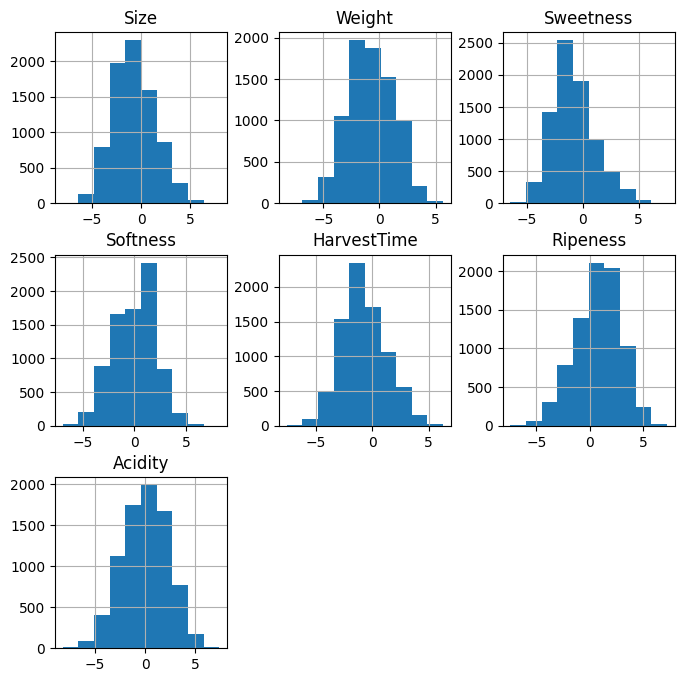

In [27]:
# Глянем распределение каждого столбца
banana_data.hist(figsize=(8, 8))

In [5]:
# Разделяем данные и нормализируем к [-1, 1]

X_train, X_test, y_train, y_test = train_test_split(banana_data.drop(columns="Quality").values, banana_data["Quality"].values, test_size=0.3)
print(X_train, y_train, sep="\n")

X_train = MinMaxScaler().fit_transform(X_train)

[[-2.2901678  -5.074038   -2.0306883  ... -4.451347   -0.03478713
  -2.5140786 ]
 [-3.666341    2.184077    0.83789104 ... -1.4484013   1.3319583
   0.491725  ]
 [ 1.7570686  -3.9802885   0.45168337 ...  1.2375456   3.4805572
  -5.7123947 ]
 ...
 [-2.5916727  -1.8984929  -0.6227332  ... -2.172158    2.10983
  -1.0392821 ]
 [ 2.2169385   0.2785105  -2.2307193  ... -0.5956906  -4.505463
   2.2108989 ]
 [-3.9187257  -0.26615655 -0.05142337 ... -1.7050734   0.41878572
   2.230764  ]]
['Bad' 'Good' 'Good' ... 'Bad' 'Bad' 'Bad']


## 2 Построение моделей

Реализовать следующие алгоритмы классификации:
* Метод опорных векторов (SVM)
* Логистическая регрессия
* Метод k-ближайших соседей

In [28]:
# Метод опорных векторов с линейным ядром
svc_model = LinearSVC().fit(X_train, y_train)
svc_pred = svc_model.predict(X_test)
svc_pred

array(['Bad', 'Bad', 'Good', ..., 'Bad', 'Bad', 'Bad'], dtype=object)

In [29]:
# Логистическая регрессия
lr_model = LogisticRegression().fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_pred

array(['Bad', 'Bad', 'Good', ..., 'Bad', 'Bad', 'Bad'], dtype=object)

In [30]:
# Метод k ближайших соседей
knn_model = KNeighborsClassifier().fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
knn_pred

array(['Bad', 'Bad', 'Good', ..., 'Bad', 'Bad', 'Bad'], dtype=object)

## 3 Оценка моделей

Сравнить результаты работы всех моделей на основе следующих метрик:
* Accuracy (Точность)
* F1-Score
* Confusion matrix (Матрица ошибок)
* PR-AUC (Precision-Recall AUC)
* ROC-AUC (Receiver Operating Characteristic AUC)

Отрисовать PR и ROC кривые для каждого класса (если задача
мультиклассовая) или для классов (если бинарная).

In [9]:
# Сравнение Accuracy
print(f"Accuracy для метода опроных векторов: {accuracy_score(y_test, svc_pred): .3f}")
print(f"Accuracy для логистической регрессии: {accuracy_score(y_test, lr_pred): .3f}")
print(f"Accuracy для k ближайших соседей: {accuracy_score(y_test, knn_pred): .3f}")

Accuracy для метода опроных векторов:  0.685
Accuracy для логистической регрессии:  0.685
Accuracy для k ближайших соседей:  0.831


In [10]:
# Сравнение f1
print(f"F1-score для метода опроных векторов: {f1_score(y_test, svc_pred, pos_label='Good'): .3f}")
print(f"F1-score для логистической регрессии: {f1_score(y_test, lr_pred, pos_label='Good'): .3f}")
print(f"F1-score для k ближайших соседей: {f1_score(y_test, knn_pred, pos_label='Good'): .3f}")

F1-score для метода опроных векторов:  0.552
F1-score для логистической регрессии:  0.555
F1-score для k ближайших соседей:  0.825


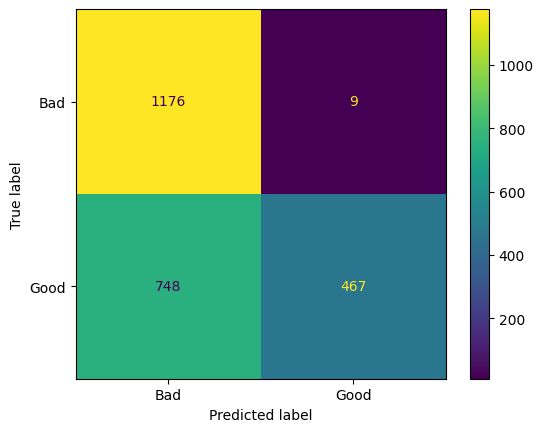

In [11]:
# Матрица ошибок для метода опроных векторов
ConfusionMatrixDisplay.from_predictions(y_test, svc_pred)

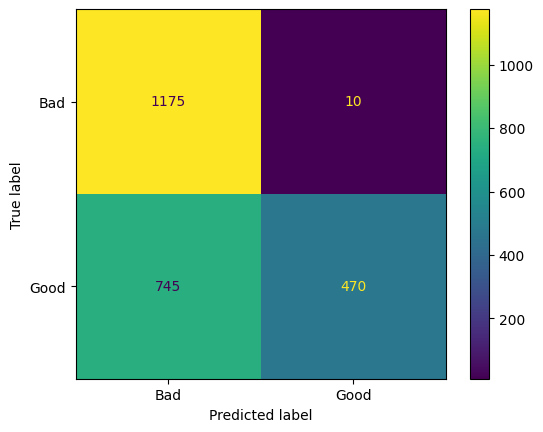

In [12]:
# Матрица ошибок для логистической регрессии
ConfusionMatrixDisplay.from_predictions(y_test, lr_pred)

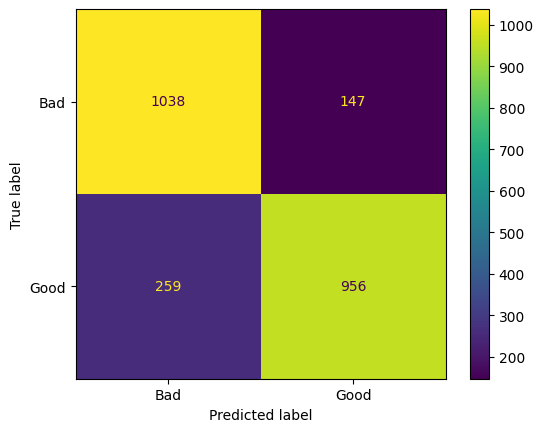

In [13]:
# Матрица ошибок для k ближайших соседей
ConfusionMatrixDisplay.from_predictions(y_test, knn_pred)

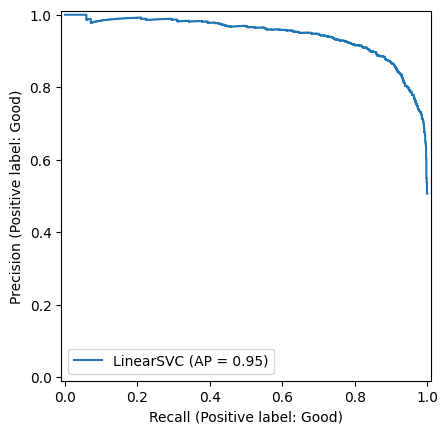

In [31]:
# PR кривая и её AUC для метода опорных векторов
PrecisionRecallDisplay.from_estimator(svc_model, X_test, y_test, pos_label="Good")

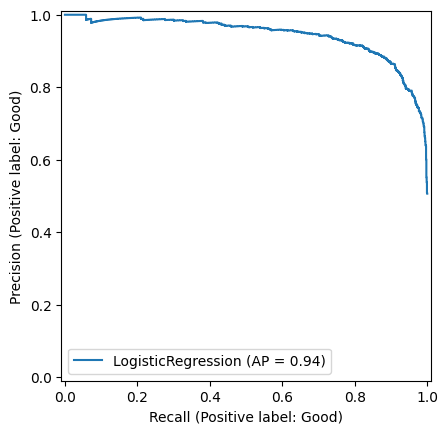

In [15]:
# PR кривая и её AUC для логистической регрессии
PrecisionRecallDisplay.from_estimator(lr_model, X_test, y_test, pos_label="Good")

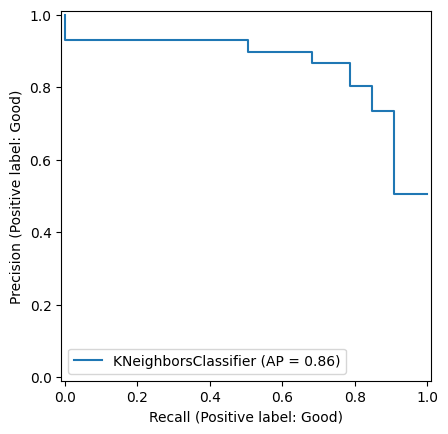

In [16]:
# PR кривая и её AUC для k ближайших соседей
PrecisionRecallDisplay.from_estimator(knn_model, X_test, y_test, pos_label="Good")

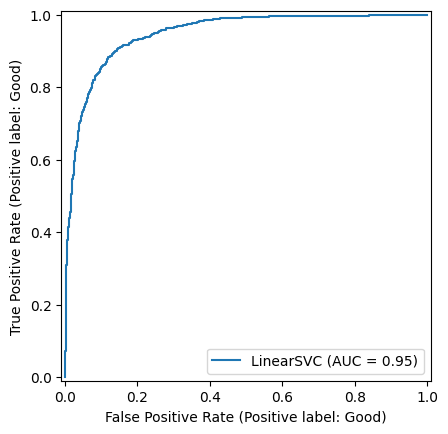

In [17]:
# ROC кривая и её AUC для метода опорных векторов
RocCurveDisplay.from_estimator(svc_model, X_test, y_test, pos_label="Good")

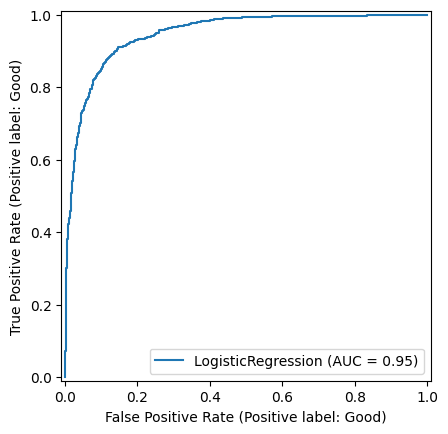

In [18]:
# ROC кривая и её AUC для логистической регрессии
RocCurveDisplay.from_estimator(lr_model, X_test, y_test, pos_label="Good")

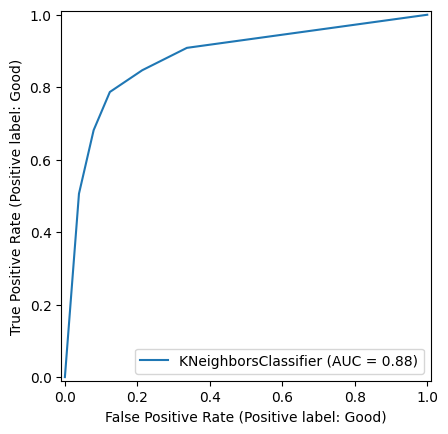

In [19]:
# ROC кривая и её AUC для k ближайших соседей
RocCurveDisplay.from_estimator(knn_model, X_test, y_test, pos_label="Good")

## 4 Оптимизация порога классификации

In [32]:
# Создаём отдельную модель
lr_model = LogisticRegression().fit(X_train, y_train)
y_probs = lr_model.predict_proba(X_test)[:, 1]
y_probs

array([1.03987015e-25, 1.15753243e-30, 9.99941327e-01, ...,
       3.65611674e-25, 3.67229215e-22, 4.67422358e-26])

In [21]:
# Оптимизируем порог при помощи PR
thresholds = np.arange(0.01, 1, 0.01)
f1_scores = np.zeros(100)
for i in range(len(thresholds)):
  y_pred = y_probs > thresholds[i]
  f1_scores[i] = f1_score(y_test == "Good", y_pred)


optimal_threshold_pr = thresholds[np.argmax(f1_scores)]
print(f"Лучший порог согласно f1 метрике: {optimal_threshold_pr}")

Лучший порог согласно f1 метрике: 0.01


In [22]:
# Оптимизируем порог при помощи G_mean
thresholds = np.arange(0.01, 1, 0.01)
f1_scores = np.zeros(100)
for i in range(len(thresholds)):
  y_pred = y_probs > thresholds[i]
  f1_scores[i] = geometric_mean_score(y_test == "Good", y_pred)


optimal_threshold_pr = thresholds[np.argmax(f1_scores)]
print(f"Лучший порог согласно G_mean метрике: {optimal_threshold_pr}")

Лучший порог согласно G_mean метрике: 0.01
